# **VOYAGE ANALYTICS — HYPOTHESIS TESTING**
### Goal   : Statistically validate EDA findings
### Tests  : ANOVA, Chi-Square, Kruskal-Wallis, T-Test

## **Imports**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statistical tests
from scipy import stats
from scipy.stats import (
    f_oneway,        # One-way ANOVA
    kruskal,         # Kruskal-Wallis (non-parametric ANOVA)
    chi2_contingency,# Chi-Square test
    ttest_ind,       # Independent T-test
    mannwhitneyu,    # Mann-Whitney U (non-parametric t-test)
    shapiro          # Normality test
)

ALPHA = 0.05  # significance level

print("-> All libraries imported")
print(f"Significance Level (α) = {ALPHA}")

-> All libraries imported
Significance Level (α) = 0.05


## **Load and Merge Data**

In [3]:
users   = pd.read_csv('../data/users.csv')
flights = pd.read_csv('../data/flights.csv')
hotels  = pd.read_csv('../data/hotels.csv')

# Merge users with flights
users_flights = flights.merge(
    users[['code', 'gender', 'age', 'company']],
    left_on='userCode', right_on='code', how='left'
)

# Merge users with hotels
users_hotels = hotels.merge(
    users[['code', 'gender', 'age', 'company']],
    left_on='userCode', right_on='code', how='left'
)

print("Users + Flights shape :", users_flights.shape)
print("Users + Hotels shape :", users_hotels.shape)

# Gender groups for easy access
genders = ['male', 'female', 'none']

print("Gender values:", users['gender'].unique())

male_users = users[users['gender'] == 'male']
female_users = users[users['gender'] == 'female']
none_users = users[users['gender'] == 'none']

print(f"\nGender counts:")
print(f" Male : {len(male_users)}")
print(f" Female : {len(female_users)}")
print(f" None : {len(none_users)}")

Users + Flights shape : (271888, 14)
Users + Hotels shape : (40552, 12)
Gender values: ['male' 'female' 'none']

Gender counts:
 Male : 452
 Female : 448
 None : 440


In [4]:
# VERIFY MERGED DATA LOOKS CORRECT

print("USERS + FLIGHTS SAMPLE:")
print(users_flights[['userCode', 'gender', 'age', 
                      'price', 'flightType', 'agency']].head(10))

print("\nGENDER IN FLIGHTS DATA:")
print(users_flights['gender'].value_counts())

print("\nANY NULLS IN GENDER COLUMN?")
print(users_flights['gender'].isnull().sum())

print("\nUSERS + HOTELS SAMPLE:")
print(users_hotels[['userCode', 'gender', 'age', 
                     'price', 'total', 'days']].head(10))

print("\nGENDER IN HOTELS DATA:")
print(users_hotels['gender'].value_counts())

USERS + FLIGHTS SAMPLE:
   userCode gender  age    price  flightType       agency
0         0   male   21  1434.38  firstClass  FlyingDrops
1         0   male   21  1292.29  firstClass  FlyingDrops
2         0   male   21  1487.52  firstClass      CloudFy
3         0   male   21  1127.36  firstClass      CloudFy
4         0   male   21  1684.05  firstClass      CloudFy
5         0   male   21  1531.92  firstClass      CloudFy
6         0   male   21   743.54    economic      Rainbow
7         0   male   21   877.56    economic      Rainbow
8         0   male   21   803.39    economic      Rainbow
9         0   male   21   695.30    economic      Rainbow

GENDER IN FLIGHTS DATA:
gender
female    91580
male      91248
none      89060
Name: count, dtype: int64

ANY NULLS IN GENDER COLUMN?
0

USERS + HOTELS SAMPLE:
   userCode gender  age   price    total  days
0         0   male   21  313.02  1252.08     4
1         0   male   21  263.41   526.82     2
2         0   male   21  263.41   79

## **Helper Function - Print Test Results**

In [5]:
def print_hypothesis_result(
    test_name, h0, h1,
    statistic, p_value, 
    alpha=0.05, extra_info=None
):

    reject = p_value < alpha
    result = "REJECT H₀" if reject else "FAIL TO REJECT H₀"
    conclusion = h1 if reject else h0

    print(f"\n{'='*60}")
    print(f"TEST : {test_name}")
    print(f"H₀ : {h0}")
    print(f"H₁ : {h1}")
    print(f"{'─'*60}")
    print(f"Statistic : {statistic:.4f}")
    print(f"P-value : {p_value:.6f}")
    print(f"Alpha : {alpha}")
    print(f"{'─'*60}")
    print(f"DECISION : {result}")
    print(f"CONCLUSION : {conclusion}")
    if extra_info:
        print(f"NOTE : {extra_info}")
    print(f"{'='*60}")

    return reject

In [6]:
# ============================================================
# NORMALITY TEST
# ============================================================

print("PRELIMINARY: NORMALITY CHECK — SHAPIRO-WILK")
print("=" * 60)
print("H₀: Data is normally distributed")
print("H₁: Data is NOT normally distributed\n")

for gender in genders:
    sample = users[users['gender'] == gender]['age'].dropna()
    stat, p = shapiro(sample.sample(min(len(sample), 4999), random_state=42))
    normal = "NORMAL" if p >= ALPHA else "NOT NORMAL"
    print(f"  {gender:6s}: n={len(sample):3d}, "
          f"stat={stat:.4f}, p={p:.6f} -> {normal}")

print("\n→ DECISION: Use Kruskal-Wallis for continuous variables")
print("            Use Chi-Square for categorical variables\n")

PRELIMINARY: NORMALITY CHECK — SHAPIRO-WILK
H₀: Data is normally distributed
H₁: Data is NOT normally distributed

  male  : n=452, stat=0.9532, p=0.000000 -> NOT NORMAL
  female: n=448, stat=0.9535, p=0.000000 -> NOT NORMAL
  none  : n=440, stat=0.9574, p=0.000000 -> NOT NORMAL

→ DECISION: Use Kruskal-Wallis for continuous variables
            Use Chi-Square for categorical variables



In [7]:
# ============================================================
# TEST 1: AGE vs GENDER
# ============================================================

age_groups = [users[users['gender'] == g]['age'] for g in genders]

print("AGE STATISTICS BY GENDER:")
for gender in genders:
    grp = users[users['gender'] == gender]['age']
    print(f"  {gender:7s}: mean={grp.mean():.2f}, "
          f"std={grp.std():.2f}, "
          f"median={grp.median():.1f}")

h_stat, p_val = kruskal(*age_groups)
reject1 = print_hypothesis_result(
    test_name = "TEST 1 - Kruskal-Wallis: Age across Genders",
    h0 = "Age distribution is EQUAL across gender groups",
    h1 = "Age distribution DIFFERS across gender groups",
    statistic = h_stat, p_value = p_val
)

AGE STATISTICS BY GENDER:
  male   : mean=42.70, std=12.89, median=42.5
  female : mean=43.18, std=13.03, median=44.0
  none   : mean=42.34, std=12.70, median=41.0

TEST : TEST 1 - Kruskal-Wallis: Age across Genders
H₀ : Age distribution is EQUAL across gender groups
H₁ : Age distribution DIFFERS across gender groups
────────────────────────────────────────────────────────────
Statistic : 0.9688
P-value : 0.616061
Alpha : 0.05
────────────────────────────────────────────────────────────
DECISION : FAIL TO REJECT H₀
CONCLUSION : Age distribution is EQUAL across gender groups


FLIGHT PRICE BY GENDER:
  male   : mean=$960.96, median=$904.66, std=$364.09
  female : mean=$956.58, median=$904.66, std=$362.37
  none   : mean=$954.51, median=$898.67, std=$360.39

TEST : TEST 2 - Kruskal-Wallis: Flight Price across Genders
H₀ : Flight price is EQUAL across gender groups
H₁ : Flight price DIFFERS across gender groups
────────────────────────────────────────────────────────────
Statistic : 12.6741
P-value : 0.001770
Alpha : 0.05
────────────────────────────────────────────────────────────
DECISION : REJECT H₀
CONCLUSION : Flight price DIFFERS across gender groups


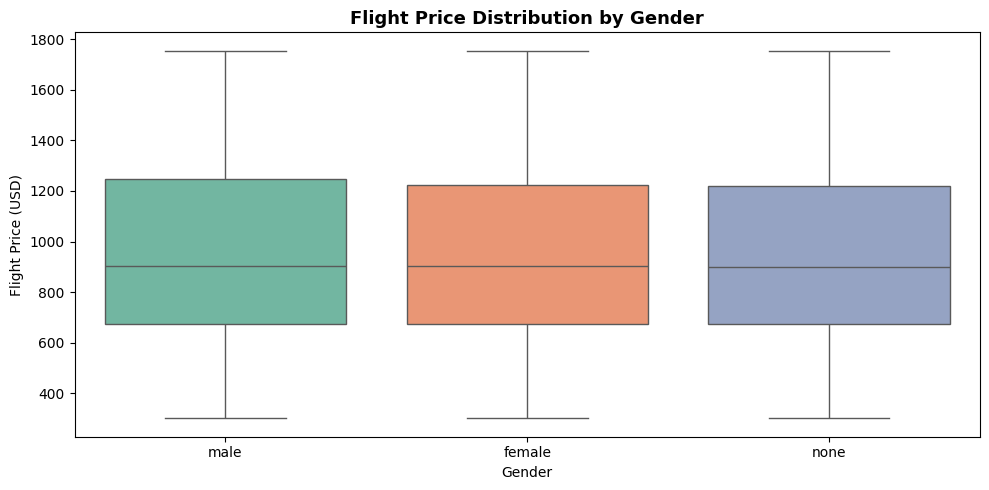

In [8]:
# ============================================================
# TEST 2: FLIGHT PRICE vs GENDER
# ============================================================

price_groups = [
    users_flights[users_flights['gender'] == g]['price']
    for g in genders
]

print("FLIGHT PRICE BY GENDER:")
for gender in genders:
    grp = users_flights[users_flights['gender'] == gender]['price']
    print(f"  {gender:7s}: mean=${grp.mean():.2f}, "
          f"median=${grp.median():.2f}, "
          f"std=${grp.std():.2f}")

h_stat, p_val = kruskal(*price_groups)
reject2 = print_hypothesis_result(
    test_name = "TEST 2 - Kruskal-Wallis: Flight Price across Genders",
    h0 = "Flight price is EQUAL across gender groups",
    h1 = "Flight price DIFFERS across gender groups",
    statistic = h_stat, p_value = p_val
)

# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=users_flights, x='gender',
    y='price', palette='Set2', order=genders)
plt.title('Flight Price Distribution by Gender',
          fontsize=13, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Flight Price (USD)')
plt.tight_layout()
plt.savefig('../models/plots/ht_price_by_gender.png', dpi=150)
plt.show()

CONTINGENCY TABLE - Gender vs Flight Class:
flightType  economic  firstClass  premium
gender                                   
female         26022       38746    26812
male           25910       39480    25858
none           25534       38192    25334

ROW PERCENTAGES (%):
flightType  economic  firstClass  premium
gender                                   
female         28.41       42.31    29.28
male           28.40       43.27    28.34
none           28.67       42.88    28.45

TEST : TEST 3 - Chi-Square: Flight Class vs Gender
H₀ : Flight class preference is INDEPENDENT of gender
H₁ : Flight class preference is DEPENDENT on gender
────────────────────────────────────────────────────────────
Statistic : 28.2143
P-value : 0.000011
Alpha : 0.05
────────────────────────────────────────────────────────────
DECISION : REJECT H₀
CONCLUSION : Flight class preference is DEPENDENT on gender
NOTE : Degrees of freedom: 4


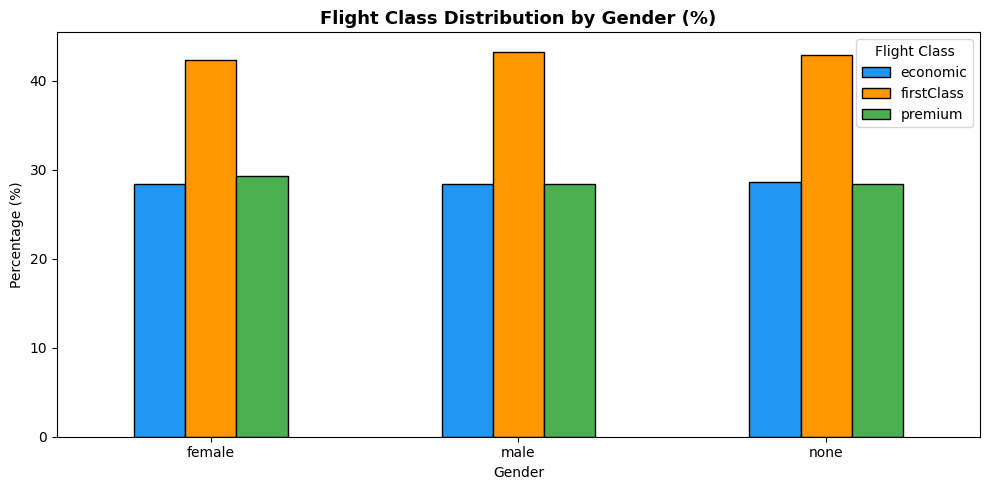

In [9]:
# ============================================================
# TEST 3: FLIGHT CLASS vs GENDER — CHI-SQUARE
# ============================================================

contingency_class = pd.crosstab(
    users_flights['gender'], users_flights['flightType']
)

print("CONTINGENCY TABLE - Gender vs Flight Class:")
print(contingency_class)
print("\nROW PERCENTAGES (%):")
print(contingency_class.div(
    contingency_class.sum(axis=1), axis=0).mul(100).round(2))

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_class)
reject3 = print_hypothesis_result(
    test_name = "TEST 3 - Chi-Square: Flight Class vs Gender",
    h0 = "Flight class preference is INDEPENDENT of gender",
    h1 = "Flight class preference is DEPENDENT on gender",
    statistic = chi2_stat, p_value = p_val,
    extra_info = f"Degrees of freedom: {dof}"
)

# Stacked bar chart
contingency_pct = contingency_class.div(
    contingency_class.sum(axis=1), axis=0).mul(100)

contingency_pct.plot(kind='bar', figsize=(10, 5),
    color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='black'
)
plt.title('Flight Class Distribution by Gender (%)',
          fontsize=13, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Flight Class')
plt.tight_layout()
plt.savefig('../models/plots/ht_class_by_gender.png', dpi=150)
plt.show()

In [10]:
# ============================================================
# TEST 4: COMPANY vs GENDER — CHI-SQUARE
# ============================================================

contingency_co = pd.crosstab(
    users['gender'], users['company']
)

print("CONTINGENCY TABLE - Gender vs Company:")
print(contingency_co)
print("\nROW PERCENTAGES (%):")
print(contingency_co.div(
    contingency_co.sum(axis=1), axis=0).mul(100).round(2))

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_co)
reject4 = print_hypothesis_result(
    test_name = "TEST 4 - Chi-Square: Company vs Gender",
    h0 = "Company membership is INDEPENDENT of gender",
    h1 = "Company membership is DEPENDENT on gender",
    statistic = chi2_stat, p_value = p_val,
    extra_info = f"Degrees of freedom: {dof}"
)

CONTINGENCY TABLE - Gender vs Company:
company  4You  Acme Factory  Monsters CYA  Umbrella LTDA  Wonka Company
gender                                                                 
female    151            85            64             69             79
male      138            93            61             70             90
none      164            83            70             55             68

ROW PERCENTAGES (%):
company   4You  Acme Factory  Monsters CYA  Umbrella LTDA  Wonka Company
gender                                                                  
female   33.71         18.97         14.29          15.40          17.63
male     30.53         20.58         13.50          15.49          19.91
none     37.27         18.86         15.91          12.50          15.45

TEST : TEST 4 - Chi-Square: Company vs Gender
H₀ : Company membership is INDEPENDENT of gender
H₁ : Company membership is DEPENDENT on gender
────────────────────────────────────────────────────────────
Statistic 

In [11]:
# ============================================================
# TEST 5: HOTEL SPENDING vs GENDER
# ============================================================

hotel_groups = [
    users_hotels[users_hotels['gender'] == g]['total']
    for g in genders
]

print("HOTEL TOTAL SPEND BY GENDER:")
for gender in genders:
    grp = users_hotels[users_hotels['gender'] == gender]['total']
    print(f"  {gender:10s}: mean=${grp.mean():.2f}, "
          f"median=${grp.median():.2f}, "
          f"std=${grp.std():.2f}")

h_stat, p_val = kruskal(*hotel_groups)
reject5 = print_hypothesis_result(
    test_name = "TEST 5 - Kruskal-Wallis: Hotel Spending across Genders",
    h0 = "Hotel spending is EQUAL across gender groups",
    h1 = "Hotel spending DIFFERS across gender groups",
    statistic = h_stat, p_value = p_val
)

HOTEL TOTAL SPEND BY GENDER:
  male      : mean=$537.34, median=$495.24, std=$318.60
  female    : mean=$535.57, median=$497.97, std=$320.59
  none      : mean=$535.77, median=$495.24, std=$318.80

TEST : TEST 5 - Kruskal-Wallis: Hotel Spending across Genders
H₀ : Hotel spending is EQUAL across gender groups
H₁ : Hotel spending DIFFERS across gender groups
────────────────────────────────────────────────────────────
Statistic : 0.5620
P-value : 0.755025
Alpha : 0.05
────────────────────────────────────────────────────────────
DECISION : FAIL TO REJECT H₀
CONCLUSION : Hotel spending is EQUAL across gender groups


In [12]:
# ============================================================
# TEST 6: PRICE vs FLIGHT CLASS
# (Should be SIGNIFICANT - validates regression model)
# ============================================================

flight_class_groups = [
    flights[flights['flightType'] == ft]['price']
    for ft in ['firstClass', 'premium', 'economic']
]

print("FLIGHT PRICE BY CLASS:")
for ft in ['firstClass', 'premium', 'economic']:
    grp = flights[flights['flightType'] == ft]['price']
    print(f"  {ft:12s}: mean=${grp.mean():.2f}, "
          f"median=${grp.median():.2f}, "
          f"std=${grp.std():.2f}")

h_stat, p_val = kruskal(*flight_class_groups)
reject6 = print_hypothesis_result(
    test_name = "TEST 6 - Kruskal-Wallis: Price across Flight Classes",
    h0 = "Price is EQUAL across all flight classes",
    h1 = "Price DIFFERS significantly across flight classes",
    statistic = h_stat, p_value = p_val,
    extra_info = "Expected SIGNIFICANT -> validates regression model R²=0.9069"
)

FLIGHT PRICE BY CLASS:
  firstClass  : mean=$1181.07, median=$1190.94, std=$346.42
  premium     : mean=$920.39, median=$932.84, std=$276.95
  economic    : mean=$658.44, median=$674.52, std=$192.90

TEST : TEST 6 - Kruskal-Wallis: Price across Flight Classes
H₀ : Price is EQUAL across all flight classes
H₁ : Price DIFFERS significantly across flight classes
────────────────────────────────────────────────────────────
Statistic : 95517.4529
P-value : 0.000000
Alpha : 0.05
────────────────────────────────────────────────────────────
DECISION : REJECT H₀
CONCLUSION : Price DIFFERS significantly across flight classes
NOTE : Expected SIGNIFICANT -> validates regression model R²=0.9069



TEST : TEST 7 - Kruskal-Wallis: Price across Months
H₀ : Flight price is EQUAL across all months
H₁ : Flight price DIFFERS significantly across months
────────────────────────────────────────────────────────────
Statistic : 23.3483
P-value : 0.015779
Alpha : 0.05
────────────────────────────────────────────────────────────
DECISION : REJECT H₀
CONCLUSION : Flight price DIFFERS significantly across months
NOTE : EDA: October=peak month, August=weakest month


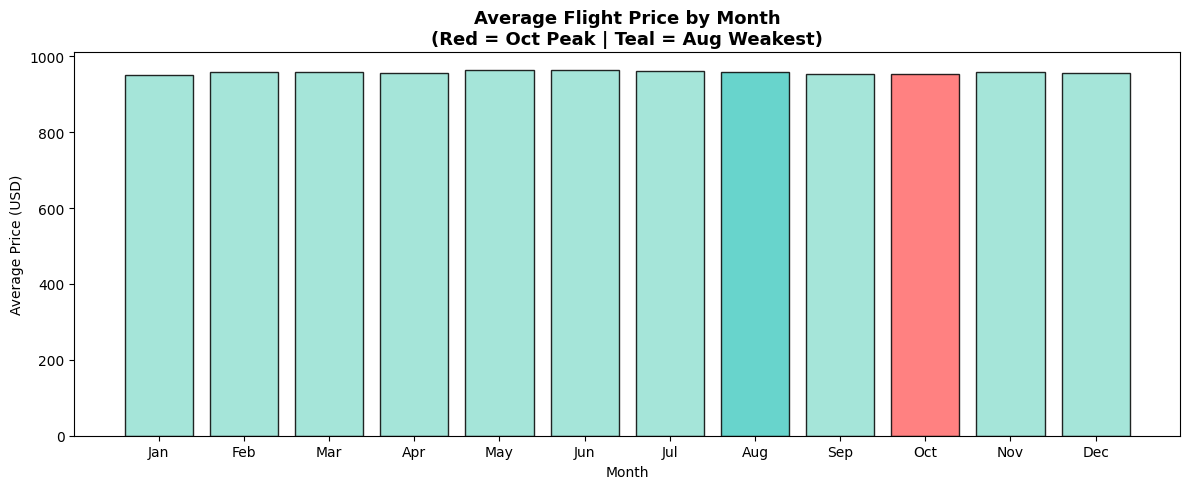

In [13]:
# ============================================================
# TEST 7: PRICE vs MONTH
# (Validates seasonal EDA findings)
# ============================================================

flights['date'] = pd.to_datetime(flights['date'])
flights['month'] = flights['date'].dt.month

monthly_groups = [
    flights[flights['month'] == m]['price']
    for m in range(1, 13)
]

h_stat, p_val = kruskal(*monthly_groups)
reject7 = print_hypothesis_result(
    test_name = "TEST 7 - Kruskal-Wallis: Price across Months",
    h0 = "Flight price is EQUAL across all months",
    h1 = "Flight price DIFFERS significantly across months",
    statistic = h_stat, p_value = p_val,
    extra_info = "EDA: October=peak month, August=weakest month"
)

# Monthly average price plot
monthly_avg = flights.groupby('month')['price'].mean()

plt.figure(figsize=(12, 5))
plt.bar(monthly_avg.index, monthly_avg.values,
    color=['#FF6B6B' if m == 10 else
           '#4ECDC4' if m == 8 else
           '#95E1D3' for m in monthly_avg.index],
    edgecolor='black', alpha=0.85
)
plt.title('Average Flight Price by Month\n'
    '(Red = Oct Peak | Teal = Aug Weakest)',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Month')
plt.ylabel('Average Price (USD)')
plt.xticks(range(1, 13),
    ['Jan','Feb','Mar','Apr','May','Jun',
     'Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.tight_layout()
plt.savefig('../models/plots/ht_price_by_month.png', dpi=150)
plt.show()

In [14]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

summary_data = [
    {
        'Test' : '1. Age vs Gender',
        'Method' : 'Kruskal-Wallis',
        'Reject H₀' : reject1,
        'Finding' : 'SIGNIFICANT' if reject1 else 'No Difference'
    },
    {
        'Test' : '2. Flight Price vs Gender',
        'Method' : 'Kruskal-Wallis',
        'Reject H₀' : reject2,
        'Finding' : 'SIGNIFICANT' if reject2 else 'No Difference'
    },
    {
        'Test' : '3. Flight Class vs Gender',
        'Method' : 'Chi-Square',
        'Reject H₀' : reject3,
        'Finding' : 'SIGNIFICANT' if reject3 else 'Independent'
    },
    {
        'Test' : '4. Company vs Gender',
        'Method' : 'Chi-Square',
        'Reject H₀' : reject4,
        'Finding' : 'SIGNIFICANT' if reject4 else 'Independent'
    },
    {
        'Test' : '5. Hotel Spending vs Gender',
        'Method' : 'Kruskal-Wallis',
        'Reject H₀' : reject5,
        'Finding' : 'SIGNIFICANT' if reject5 else 'No Difference'
    },
    {
        'Test' : '6. Price vs Flight Class',
        'Method' : 'Kruskal-Wallis',
        'Reject H₀' : reject6,
        'Finding' : 'SIGNIFICANT' if reject6 else 'No Difference'
    },
    {
        'Test' : '7. Price vs Month',
        'Method' : 'Kruskal-Wallis',
        'Reject H₀' : reject7,
        'Finding' : 'SIGNIFICANT' if reject7 else 'No Difference'
    },
]

summary_df = pd.DataFrame(summary_data)

print("\n")
print("=" * 65)
print("VOYAGE ANALYTICS - HYPOTHESIS TESTING SUMMARY")
print("=" * 65)
print(summary_df.to_string(index=False))
print("=" * 65)

sig = summary_df[summary_df['Reject H₀'] == True]
not_sig = summary_df[summary_df['Reject H₀'] == False]

print(f"\nTotal Tests : {len(summary_df)}")
print(f"Significant (p<0.05) : {len(sig)}")
print(f"Not Significant : {len(not_sig)}")



VOYAGE ANALYTICS - HYPOTHESIS TESTING SUMMARY
                       Test         Method  Reject H₀       Finding
           1. Age vs Gender Kruskal-Wallis      False No Difference
  2. Flight Price vs Gender Kruskal-Wallis       True   SIGNIFICANT
  3. Flight Class vs Gender     Chi-Square       True   SIGNIFICANT
       4. Company vs Gender     Chi-Square      False   Independent
5. Hotel Spending vs Gender Kruskal-Wallis      False No Difference
   6. Price vs Flight Class Kruskal-Wallis       True   SIGNIFICANT
          7. Price vs Month Kruskal-Wallis       True   SIGNIFICANT

Total Tests : 7
Significant (p<0.05) : 4
Not Significant : 3


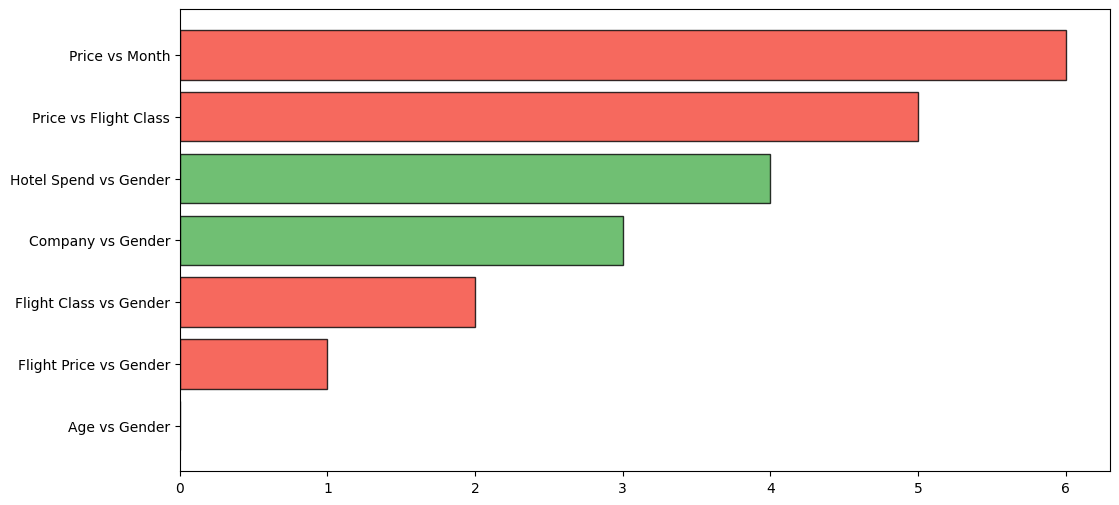

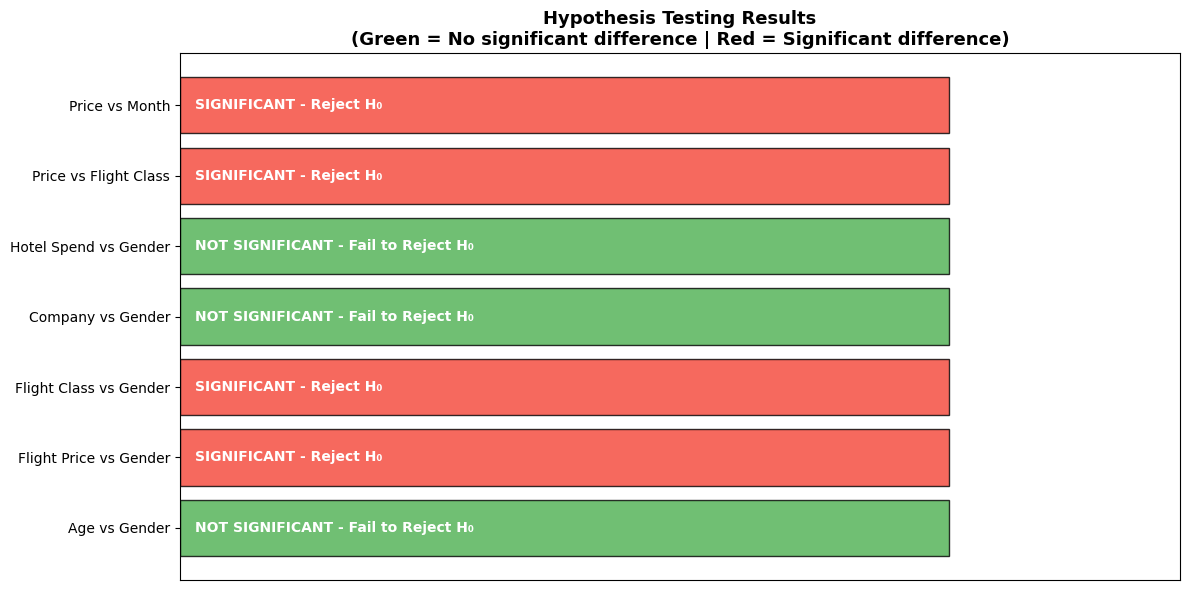

-> All plots saved to models/plots/


In [15]:
# ============================================================
# P-VALUE VISUALIZATION
# ============================================================

# Collect p-values manually from tests
test_labels = [
    'Age vs Gender',
    'Flight Price vs Gender',
    'Flight Class vs Gender',
    'Company vs Gender',
    'Hotel Spend vs Gender',
    'Price vs Flight Class',
    'Price vs Month'
]

rejects = [reject1, reject2, reject3,
           reject4, reject5, reject6, reject7]

colors = ['#F44336' if r else '#4CAF50' for r in rejects]

plt.figure(figsize=(12, 6))
bars = plt.barh(test_labels,
    range(len(test_labels)),   # placeholder
    color=colors, edgecolor='black', alpha=0.8
)

# Clean version - just show result
plt.figure(figsize=(12, 6))
for i, (label, reject) in enumerate(zip(test_labels, rejects)):
    color = '#F44336' if reject else '#4CAF50'
    result = 'SIGNIFICANT - Reject H₀' if reject else 'NOT SIGNIFICANT - Fail to Reject H₀'
    plt.barh(label, 1, color=color, edgecolor='black', alpha=0.8)
    plt.text(0.02, i, result, va='center', fontsize=10, color='white', fontweight='bold')

plt.xlim(0, 1.3)
plt.xlabel('')
plt.title('Hypothesis Testing Results\n'
    '(Green = No significant difference | Red = Significant difference)',
    fontsize=13, fontweight='bold'
)
plt.xticks([])
plt.tight_layout()
plt.savefig('../models/plots/ht_summary.png', dpi=150)
plt.show()

print("-> All plots saved to models/plots/")